# Nguồn dataset: https://www.kaggle.com/datasets/lehoanglonglong/smallsongs2

**Tên bài tập:** hust, song classification using bert

**Mô tả ngắn về dataset mà em dùng:** Ở trong data của tác giả, em thấy trong đó có 2 file là *generative_ai_misinformation_dataset.csv* và *l_df.csv* và em chọn datatset *l_df.csv* để đưa vào pipline mô hình. Dataset *l_df.csv* là một tập dữ liệu dùng cho bài toán phân loại thể loại nhạc dựa trên lời bài hát (lyrics classification). Dataset gồm 24.803 mẫu dữ liệu và 3 cột chính: Genre, S_Lyric, và Genre_Index. Cột S_Lyric chứa nội dung lời bài hát, đóng vai trò là input văn bản cho mô hình NLP. Cột Genre biểu thị thể loại của bài hát (ví dụ: Country, Hip-Hop, Electronic). Cột Genre_Index là mã số của thể loại, được dùng làm label số để huấn luyện mô hình machine learning hoặc deep learning. Dataset này thường được sử dụng để huấn luyện các mô hình NLP như BERT nhằm dự đoán thể loại nhạc từ lời bài hát. Tổng thể, đây là một dataset text classification trong lĩnh vực xử lý ngôn ngữ tự nhiên (NLP).

**Phương pháp áp dụng:** Em sử dụng mô hình BERT để phân loại thể loại nhạc dựa trên lời bài hát. Sau đó em có thể áp dụng các kỹ thuật như fine-tuning để cải thiện độ chính xác của mô hình hay là sử dụng model khác để so sánh độ hiểu quả cũng như sử dụng lời bài hát tiếng Việt hay vì tiếng Anh để kiểm tra xem độ hiệu quả của mô hình ( tại vì mô hình hiện tại chủ yếu chỉ hiệu quả tốt trên Tiếng Anh và ít dành cho Tiếng Việt )


# 1 Import các thư viện cần thiết

## 1.1 Cài đặt các thư viện

In [1]:
!pip install transformers
!pip install torch
!pip install scikit-learn
!pip install pandas
!pip install matplotlib


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1.2 Import các thư viện

In [ ]:
#thư viện hệ thống
import pandas as pd
import numpy as np
import torch

#thử viện cho mô hình
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import BertTokenizer, BertModel, AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#thư viện cho trực quan
import matplotlib.pyplot as plt

c:\Users\HOANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
W0307 18:09:59.142000 35664 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
c:\Users\HOANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [30]:
#phần thư viện bổ sung để phục vụ cho model mới
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [35]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
from sklearn.metrics import accuracy_score

In [39]:
import joblib

# 2 Import dữ liệu

In [4]:
df = pd.read_csv("l_df.csv")

print(df.shape)
df.head(10)

(24803, 3)


,Genre,S_Lyric,Genre_Index
0,Country,more than twice You'd better have somethin' in...,0
1,Hip-Hop,I'm the wrong one to play with I came to outwo...,1
2,Hip-Hop,"I got tats all on my arm, Racks on racks in th...",1
3,Hip-Hop,"so why pass it) Hey yo, I ain't bringing they ...",1
4,Electronic,"Battersea how it is It's over, forget Memories...",2
5,Hip-Hop,the real hardcore yo i'm gonna show you differ...,1
6,Electronic,"My baby was born in a bed With white sheets, m...",2
7,Electronic,The best things in life are free But you can k...,2
8,Country,music and lyrics by Corb Lund I have sinned so...,0
9,Electronic,in a trance And he never leaves the disco alon...,2


**Giải thích:** 
* Cột Genre là nhãn ( label text ) nó nghĩa là tên của thể loại bài hát, đóng vai trò chính là: hiểu bài hát thể loại gì và dùng để giải thích hay xem mức độ hiệu quả của mô hình. Nó sẽ hoạt động theo cơ chế: **Lyrics → Model → Hip-Hop**

* Cột Lyrics là dữ liệu đầu vào ( input text ) nó là nội dung bài hát, nó sẽ hoạt động theo cơ chế: **S_Lyric -> BERT tokenizer -> BERT model -> Prediction**

* Cột Genre_Index là nhãn số ký tự của thể loại nhạc (label number): Nó sẽ hoạt động theo cơ chế: Lần lượt ta có các (Country -> 0, Hip-Hop -> 1, Rock -> 2) và sau đó Model output -> [0.1, 0.7, 0.2], Argmax -> 1, -> Hip-Hop

# 3 EDA dữ liệu

In [5]:
df["Genre"].value_counts()

Genre
Hip-Hop       9820
R&B           6978
Electronic    4325
Country       3680
Name: count, dtype: int64

**Nhận xét:** Ở trên bạn có thể thấy được số lượng của từng thể loại nhạc.

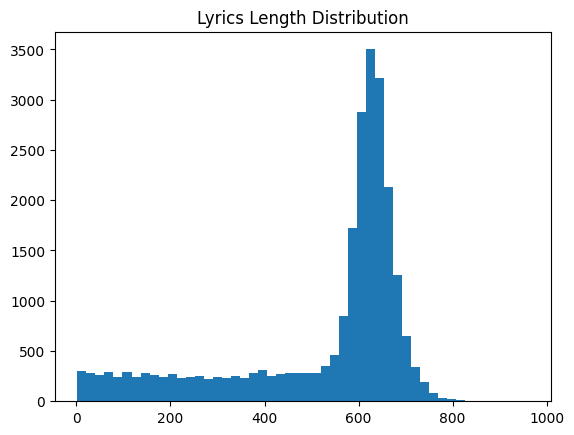

In [6]:
df["length"] = df["S_Lyric"].apply(len)

plt.hist(df["length"], bins=50)
plt.title("Lyrics Length Distribution")
plt.show()

**Nhận xét:** Ở trên thể hiện được độ dài lyrics, cụ thể là:

* Phần lớn lyrics tập trung trong khoảng khoảng 550 – 700 ký tự. Đây là vùng có cột cao nhất, nghĩa là đa số bài hát có độ dài quanh mức này.

* Một số bài hát rất ngắn (dưới ~200 ký tự) nhưng số lượng khá ít.

* Có một số bài dài hơn (~700–900 ký tự) nhưng cũng không nhiều.

* Phân bố không hoàn toàn đều, mà tập trung thành một cụm lớn quanh ~600 ký tự, cho thấy dataset khá đồng nhất về độ dài lời bài hát.


# 4 Train test split

In [ ]:
texts = df["S_Lyric"]
labels = df["Genre_Index"]

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts,
    labels,
    test_size=0.2, #chia 20% dữ liệu làm validation, 80% làm train
    random_state=42
)

**Vì sau phần này là các phần mới bắt đầu tìm hiểu nên sẽ được giải thích chi tiết kĩ về các kĩ thuật 1 chút.**

# 5 Load BERT Tokenizer

**Ý nghĩa:** là bước rất quan trọng trong pipeline NLP vì nó chuyển văn bản (lyrics) thành dạng số để mô hình BERT có thể hiểu và xử lý.

In [8]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

c:\Users\HOANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

**Giải thích:** Theo em Dòng này dùng thư viện HuggingFace Transformers để tải tokenizer của mô hình BERT đã được huấn luyện trước trên thư viện HuggingFace ( có thể lên trên web huggingface.co/models để xem các mô hình BERT có sẵn ) nên việc áp dụng cũng khá đơn giản.

**Cụ thể:** 

| Thành phần        | Ý nghĩa                                   |
|-------------------|--------------------------------------------|
| `BertTokenizer`   | công cụ dùng để tách văn bản thành token   |
| `from_pretrained()` | tải tokenizer đã được huấn luyện sẵn     |
| `"bert-base-uncased"` | phiên bản BERT được sử dụng           |

**Ngoài ra:** Tokenizer là công cụ để:

* 1 Nó sẽ thực hiện theo cơ chế Text -> Token -> ID số (Vì mô hình deep learning không hiểu chữ, nó chỉ hiểu số.)

*Ví dụ:* 

| Lyrics ban đầu | Tokenized | ID số |
|----------------|-----------|-------|
| "I love music" | ["i", "love", "this", "song"] | [1045, 2293, 2023, 2299] |

* 2 Vì sao phải dùng tokenizer của BERT

Vì mỗi mô hình NLP có từ điển riêng (vocabulary), và đặc biệt: BERT đã được huấn luyện với khoảng: ~30,000 token. 

*Ví dụ:*

| Word | Token ID |
|------|----------|
| "music" | 2189 |
| "love" | 2293 |
| "song" | 2299 |

Vậy nếu dùng tokenizer khác: mô hình sẽ không hiểu nên vì vậy phải dùng đúng tokenizer của BERT.

* 3 Ý nghĩa của "bert-base-uncased" Đây là một phiên bản BERT phổ biến, cụ thể là:

| Thành phần | Ý nghĩa |
|------------|---------|
| bert | mô hình BERT |
| base | kích thước nhỏ, phù hợp cho nhiều ứng dụng |
| uncased | không phân biệt chữ hoa chữ thường |

Ví dụ: ( LOVE, Love, love ) đều được coi là cùng là love. Điều này giúp tôi ưu, giảm lượng token làm cho mô hình học tốt

* 4 Đồng thời có thể thấy 3 file ở trên kia được tải về (tokenizer_config.json và config.json, vocab.txt)

*Ý nghĩa:*

| File | Ý nghĩa |
|------|---------|
| tokenizer_config.json | Cấu hình của tokenizer |
| config.json | Cấu hình của mô hình BERT |
| vocab.txt | Từ điển của tokenizer |

* 5 Tokenizer hoạt động như thế nào trong pipeline:

Nó sẽ hoạt động theo quy trình là: Lyrics (text) -> BERT Tokenizer -> Token IDs -> Attention Mask -> BERT Model -> Prediction (genre)

Tokenizer sẽ tạo ra:

| Thành phần | Ý nghĩa |
|------------|---------|
| input_ids | ID số của từng token |
| Attention Mask | Chỉ ra token nào là thực sự có nghĩa, token nào là padding |

# 6 PyTorch dataset

dùng để tạo một lớp dữ liệu tùy chỉnh để PyTorch có thể đọc và đưa dữ liệu vào mô hình BERT trong quá trình huấn luyện. Đây là bước trung gian giữa dataset (lyrics + label) và DataLoader / model training.

In [ ]:
class LyricsDataset(Dataset): #1

    def __init__(self, texts, labels): #2
        self.texts = texts
        self.labels = labels

    def __len__(self): #3
        return len(self.texts)

    def __getitem__(self, idx): #4

        encoding = tokenizer( #5
            self.texts.iloc[idx],
            padding="max_length", #6
            truncation=True, #7
            max_length=128, #8
            return_tensors="pt" #9 Chuyển output sang PyTorch tensor.
        )

        return {
            "input_ids": encoding["input_ids"].flatten(), 
            "attention_mask": encoding["attention_mask"].flatten(), #10, #11
            "labels": torch.tensor(self.labels.iloc[idx]) #12
        }

**Giải thích:**

* 1 Dòng này tạo một lớp dữ liệu tùy chỉnh (custom dataset) cho PyTorch, giúp chuyển đổi dữ liệu từ định dạng text (lyrics) thành định dạng số (token IDs) mà mô hình BERT có thể hiểu được. Hoạt động theo quy trình: Dataset gốc (pandas dataframe) -> LyricsDataset -> PyTorch DataLoader -> BERT model

* 2 Hàm này dùng để lưu dữ liệu đầu vào của dataset.

| Biến | Ý nghĩa |
|------|---------|
| texts | Danh sách các bài hát (lyrics) |
| labels | Danh sách các thể loại nhạc tương ứng |
| tokenizer | Công cụ chuyển đổi text thành token IDs |
| max_length | Độ dài tối đa của sequence (chuỗi token)

* 3 Hàm này trả về tổng số mẫu dữ liệu trong dataset.

* 4 Hàm này cho phép PyTorch lấy một mẫu dữ liệu theo index.

* 5 Tokenize lyrics, ở đây: lyrics -> BERT tokenizer 

*Ví dụ:* 

| Lyrics ban đầu | Tokenized | 
|----------------|-----------|
| "I love music" | [CLS] i love this music [SEP] |

Và sau đó mới chuyển thành token IDs.

* 6 Padding: Tất cả câu sẽ được padding về cùng độ dài.

*Ví dụ:*

| Câu | Token |
|-----|-------|
| "I love music" | 5 tokens |
| "This song is amazing tonight" | 8 tokens |

* 7 Truncation: Nếu câu quá dài (> max_length) thì sẽ bị cắt ngắn.

*Ví dụ:* max_length = 128 mà nếu lyrics dài 200 token thì sẽ bị cắt xuống 128 token.

* 8 Max length: tức là mỗi lyrics tối đa 128 tokens.

*Lý do:* BERT tối đa 512 tokens nhưng 128 giúp train nhanh hơn

* 10 attention_mask giúp BERT biết đâu là token thật và đâu là padding.

*Ví dụ:* 

| Token | Attention Mask |
|-------|----------------|
| "i" | 1 |
| "love" | 1 |
| [PAD] | 0 |
| [PAD] | 0 |

* 11 Flatten

*lý do:* Do tokenizer trả về dạng: tensor([[101, 1045, 2293, ...]]) nên Flatten sẽ chuyển thành: tensor([101, 1045, 2293, ...]) để DataLoader dễ xử lý. 

* 12 Label

*Ví dụ:*

| Genre | Label |
|-------|-------|
| Rock | 3 |
| HipHop | 1 |
| Country | 0 |
| Electronic| 2 |

Từ đó model sẽ học được mối quan hệ giữa lyrics và genre.

# 7 DataLoader

In [ ]:
train_dataset = LyricsDataset(train_texts, train_labels)
val_dataset = LyricsDataset(val_texts, val_labels)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

# 8 Model BERT Classification

là bước xây dựng mô hình học máy dùng BERT để phân loại thể loại nhạc từ lyrics. Đây là phần trung tâm của toàn bộ notebook, vì nó định nghĩa cách mô hình nhận dữ liệu và tạo ra dự đoán.

In [ ]:
class BertClassifier(nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask): #3 
        outputs = self.bert( #4 Đưa dữ liệu vào mô hình BERT 
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled = outputs.pooler_output # 5 Lấy ra vector đặc trưng từ BERT 
        x = self.dropout(pooled) # 6 Áp dụng dropout để tránh overfitting
        return self.fc(x) # 7 Dự đoán genre

**Giải thích:** 

* 1 Dropout Layer: Dropout giúp giảm overfitting, cách hoạt động: Trong quá trình train, dropout sẽ tắt ngẫu nhiên 30% neuron.

*Ví dụ:*

vector từ BERT: [0.5, 0.2, 0.8, 0.1]

sau khi dropout 30%: [0.5, 0, 0.8, 0.1]

* 2 Fully Connected Layer: Layer này chuyển vector từ BERT thành xác suất của các thể loại nhạc với BERT out: 768 features

*Ví dụ:* [0.23, 0.11, -0.67, 0.89, ...] thì Fully connected layer sẽ biến nó thành: [score_genre1, score_genre2, score_genre3, score_genre4]

*Ví dụ:* [1.2, 0.3, 2.1, -0.5] Sau đó argmax sẽ chọn: genre = 2 

* 3 Hàm forward: Đây là hàm chạy dữ liệu qua mô hình, mỗi lần training hoặc prediction, dữ liệu sẽ đi qua hàm này.

* 5 Ví dụ: [0.24, -0.18, 0.92, ...] Vector này chứa ngữ nghĩa của cả lyrics.

# 9 Khởi tạo model

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = df["Genre_Index"].nunique()
model = BertClassifier(num_classes)
model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

# 10 Optimizer và Loss

In [13]:
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()

c:\Users\HOANG\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


**Giải thích:** Ở đây có 2 thành phần chính:

* Optimizer: cập nhật trọng số của mô hình

* Loss Function: đo lường sai số giữa dự đoán và thực tế

# 11 Training Loop

bước mà mô hình thực sự học từ dữ liệu. Trong bước này, dữ liệu lyrics sẽ được đưa qua BERT, tính sai số (loss), sau đó optimizer cập nhật trọng số để mô hình dự đoán tốt hơn

In [ ]:
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device) #1 Lấy dữ liệu từ bacth
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad() #2 Reset gradient
        outputs = model(input_ids, attention_mask) #3 Dự đoán
        loss = loss_fn(outputs, labels) #4 Tính loss
        loss.backward() #5 Backpropagation
        optimizer.step() #6 Cập nhật weight
        total_loss += loss.item() #7 Cộng loss
    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader)}")

Epoch 1 Loss: 0.8454057121233629
Epoch 2 Loss: 0.5801654113314019
Epoch 3 Loss: 0.32234427795462506


# 12 Evaluation

bước đánh giá mô hình sau khi đã train xong. Ở đây mô hình sẽ không học nữa, mà chỉ dùng để dự đoán trên tập validation rồi so sánh với nhãn thật để đo hiệu suất.

**Giải thích:** Khác với model.train() thì Trong eval():

* dropout bị tắt

* mô hình hoạt động ổn định

* không cập nhật trọng số

Điều này giúp kết quả đánh giá chính xác hơn. (do trong eval() đã chuyển sang chế độ đánh giá rồi)

In [ ]:
model.eval()

predictions = [] #1
true_labels = [] #1

with torch.no_grad(): #2 Tắt tính gradient để không cập nhật weight giảm thiểu tối đa các vấn đề về RAM yếu

    for batch in val_loader: #3 Duyệt qua từng batch của validation set 
        input_ids = batch["input_ids"].to(device) #4 Lấy dữ liệu từ batch
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy()) #kết quả mô hình dự đoán
        true_labels.extend(labels.cpu().numpy()) #nhãn thật của dataset

**Giải thích:** 

* 1 Tạo danh sách lưu kết quả. Sau khi chạy xong kết quả lần lượt là: predictions = [1,2,0,3,1,2,...]
và true_labels = [1,1,0,3,2,2,...]

In [21]:
model.eval()

train_predictions = []
train_true_labels = []
with torch.no_grad():

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)
        train_predictions.extend(preds.cpu().numpy())
        train_true_labels.extend(labels.cpu().numpy())

# 13 Xem Accuracy và F1

In [24]:
train_acc = accuracy_score(train_true_labels, train_predictions)
print("Train Accuracy:", train_acc)
print("Accuracy:", accuracy_score(true_labels, predictions))
print(classification_report(true_labels, predictions))

Train Accuracy: 0.9666868259248059
Accuracy: 0.738359201773836
              precision    recall  f1-score   support

           0       0.72      0.73      0.72       719
           1       0.90      0.79      0.84      2001
           2       0.61      0.67      0.64       852
           3       0.64      0.71      0.67      1389

    accuracy                           0.74      4961
   macro avg       0.72      0.72      0.72      4961
weighted avg       0.75      0.74      0.74      4961



**Chú thích:** Ở đây có thể thấy lần lượt là Train Accuracy: 96% còn Val Accuracy: 74%. Vậy từ đó có thể thấy model nhớ dữ liệu train quá tốt nhưng generalize kém hơn trên dữ liệu mới

# 14 Phần thông số sau khi huấn luyện mô hình

# 14.1 Confusion Matrix

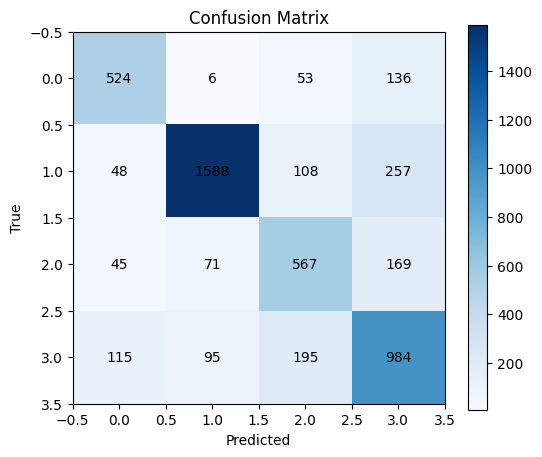

In [25]:
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

**Nhận xét:**

| Class   | Dự đoán đúng | Tổng mẫu | Accuracy class |
|---------|--------------|----------|----------------|
| Class 0 | 524          | 719      | 72.9%          |
| Class 1 | 1588         | 2001     | 79.3%          |
| Class 2 | 567          | 852      | 66.5%          |
| Class 3 | 984          | 1389     | 70.8%          |


- Class 1 được dự đoán tốt nhất (1588 mẫu đúng).
- Class 2 là khó nhất (F1-score thấp nhất ~0.64).
- Model thường nhầm Class 1 -> Class 3 và Class 3 -> Class 2.

# 15 Mở rộng: triển khai các mô hình khác

**Mục đích:** Phục vụ cho việc so sánh hiệu suất giữa các mô hình khác nhau

## 15.1 Model TF-IDF + Logistic Regression

**Phần trên đã có triển khai phần thư viện của mô hình này**

### 1 Vectorize lyrics

Ở đây thực hiện: Lyrics -> TF-IDF vector -> model

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(train_texts)
X_val_tfidf = vectorizer.transform(val_texts)

### 2 Train model

In [32]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, train_labels)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 3 Predict

In [33]:
lr_predictions = lr_model.predict(X_val_tfidf)

### 4 Evaluate

In [34]:
print("Logistic Regression Accuracy:",
      accuracy_score(val_labels, lr_predictions))

print(classification_report(val_labels, lr_predictions))

Logistic Regression Accuracy: 0.6946180205603709
              precision    recall  f1-score   support

           0       0.65      0.57      0.61       719
           1       0.82      0.84      0.83      2001
           2       0.58      0.49      0.53       852
           3       0.60      0.68      0.64      1389

    accuracy                           0.69      4961
   macro avg       0.66      0.64      0.65      4961
weighted avg       0.69      0.69      0.69      4961



## 15.2 Random Forest

**Phần trên đã có triển khai phần thư viện của mô hình này**

### 1 Train

In [36]:
rf_model = RandomForestClassifier(n_estimators=200)

rf_model.fit(X_train_tfidf, train_labels)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 2 Predict

In [37]:
rf_predictions = rf_model.predict(X_val_tfidf)

### 3 Evaluate

In [38]:
print("Random Forest Accuracy:",
      accuracy_score(val_labels, rf_predictions))

print(classification_report(val_labels, rf_predictions))

Random Forest Accuracy: 0.6420076597460189
              precision    recall  f1-score   support

           0       0.74      0.23      0.35       719
           1       0.74      0.87      0.80      2001
           2       0.63      0.26      0.37       852
           3       0.52      0.76      0.62      1389

    accuracy                           0.64      4961
   macro avg       0.66      0.53      0.53      4961
weighted avg       0.66      0.64      0.61      4961



# 16 Lưu model

## 16.1 Lưu mô hình BERT 

In [26]:
torch.save(model.state_dict(), "bert_song_classifier.pth")

In [ ]:
#Chạy khi cần sử dụng lại mô hình
model = BertClassifier(num_classes)
model.load_state_dict(torch.load("bert_song_classifier.pth"))
model.eval()

## 16.2 Lưu mô hình Model TF-IDF + Logistic Regression

In [40]:
joblib.dump(lr_model, "logistic_regression_model.pkl")

['logistic_regression_model.pkl']

In [42]:
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

## 16.3 Lưu mô hình Model Random Forest

In [41]:
joblib.dump(rf_model, "random_forest_model.pkl")

['random_forest_model.pkl']

In [ ]:
# Chạy khi cần sử dụng lại mô hình 
lr_model = joblib.load("logistic_regression_model.pkl")
rf_model = joblib.load("random_forest_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# 17 Demo mô hình khác nhau

In [ ]:
def predict_genre(text):
    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    input_ids = encoding["input_ids"]
    attention_mask = encoding["attention_mask"]
    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
    pred = torch.argmax(outputs, dim=1).item()
    return pred

In [28]:
predict_genre("I got the rhythm and the beat")

2

Mô hình dự đoán cho ra kết quả thuộc thể loại là: `Electronic`